In [2]:
import mne
from mne.datasets import eegbci

subject = 1
runs = [6]

raw_fnames = eegbci.load_data(subject, runs)
raw = mne.io.read_raw_edf(raw_fnames[0], preload=True)

raw

Extracting EDF parameters from C:\Users\10283\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [3]:
print(raw)
print(raw.info["sfreq"])
print(len(raw.ch_names))
print(raw.ch_names[:10])
raw.info.keys()

<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
160.0
64
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']


dict_keys(['acq_pars', 'acq_stim', 'ctf_head_t', 'description', 'dev_head_t', 'dev_ctf_t', 'dig', 'experimenter', 'utc_offset', 'device_info', 'file_id', 'highpass', 'hpi_subsystem', 'kit_system_id', 'helium_info', 'line_freq', 'lowpass', 'meas_date', 'meas_id', 'proj_id', 'proj_name', 'subject_info', 'xplotter_layout', 'gantry_angle', 'bads', 'chs', 'comps', 'events', 'hpi_meas', 'hpi_results', 'projs', 'proc_history', 'custom_ref_applied', 'sfreq', 'ch_names', 'nchan'])

Using matplotlib as 2D backend.


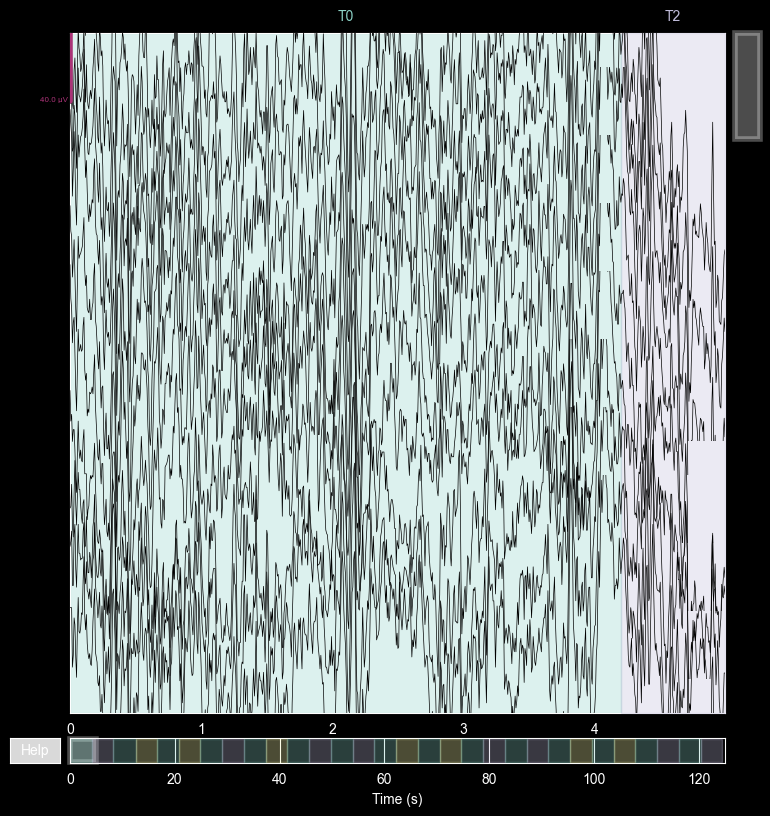

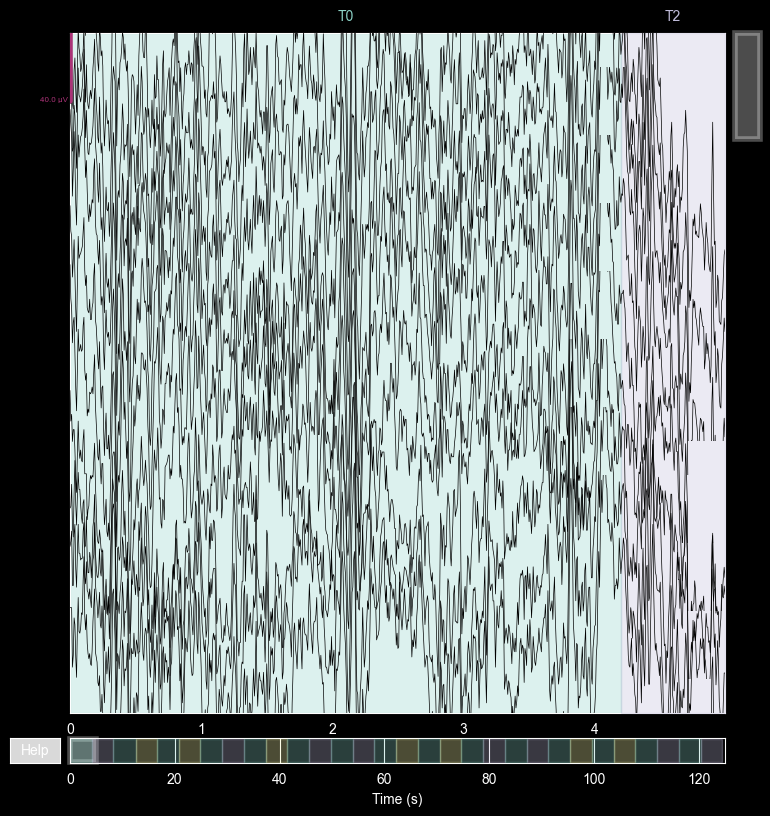

In [4]:
raw.plot(n_channels=10, duration=5)

In [5]:
events, event_id = mne.events_from_annotations(raw)

print(events[:10])
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [6]:
picks = mne.pick_types(raw.info, eeg=True, exclude="bads")

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-1.0,
    tmax=4.0,
    picks=picks,
    baseline=None,
    preload=True
)

epochs

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 801 original time points ...
1 bad epochs dropped


<Epochs | 29 events (all good), -1 – 4 s (baseline off), ~11.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>

In [7]:
print(event_id)
print(epochs)
print(epochs.get_data().shape)
epochs[event_id.keys().__iter__().__next__()]

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
<Epochs | 29 events (all good), -1 – 4 s (baseline off), ~11.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>
(29, 64, 801)


<Epochs | 14 events (all good), -1 – 4 s (baseline off), ~5.5 MiB, data loaded,
 np.str_('T0'): 14>

In [8]:
label_meaning = {
    "T0": "rest",
    "T1": "both fists",
    "T2": "both feet"
}

print("event_id:", event_id)
print("label meaning:", label_meaning)

event_id: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
label meaning: {'T0': 'rest', 'T1': 'both fists', 'T2': 'both feet'}


In [9]:
import numpy as np
import pandas as pd

data = epochs.get_data()
labels_int = epochs.events[:, -1]

inv_event_id = {v: k for k, v in event_id.items()}
labels_name = np.array([inv_event_id[x] for x in labels_int])

print("data shape:", data.shape)
print("first 10 labels:", labels_name[:10])

data shape: (29, 64, 801)
first 10 labels: ['T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2' 'T0' 'T1' 'T0']


In [10]:
label_counts = pd.Series(labels_name).value_counts().sort_index()
print(label_counts)

T0    14
T1     7
T2     8
Name: count, dtype: int64


In [11]:
print("single epoch shape:", data[0].shape)
print("time points:", len(epochs.times))
print("time range:", epochs.times[0], "to", epochs.times[-1])

single epoch shape: (64, 801)
time points: 801
time range: -1.0 to 4.0


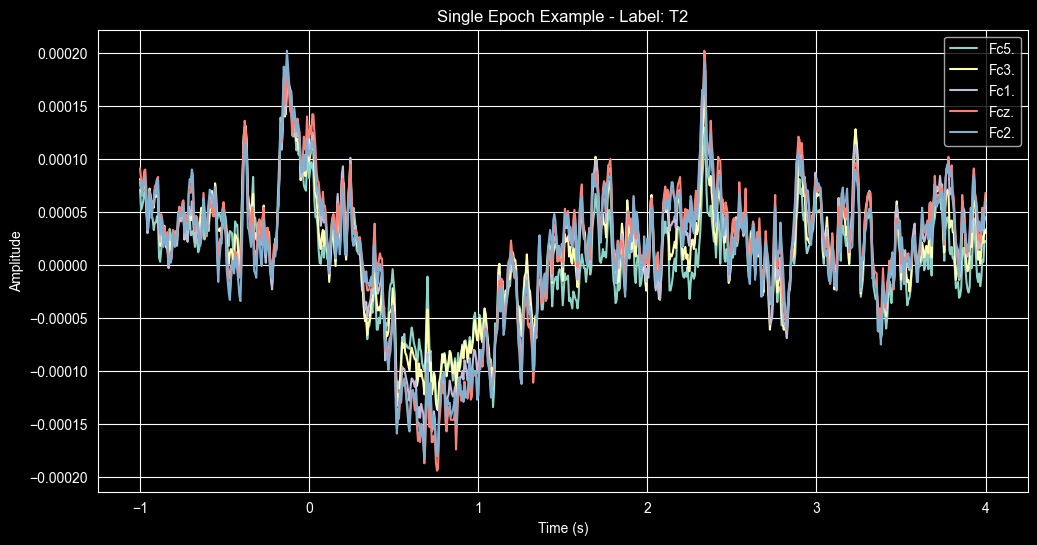

In [12]:
import matplotlib.pyplot as plt

sample_idx = 0
channels_to_plot = [0, 1, 2, 3, 4]

plt.figure(figsize=(12, 6))
for ch in channels_to_plot:
    plt.plot(epochs.times, data[sample_idx, ch, :], label=epochs.ch_names[ch])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Single Epoch Example - Label: {labels_name[sample_idx]}")
plt.legend()
plt.show()

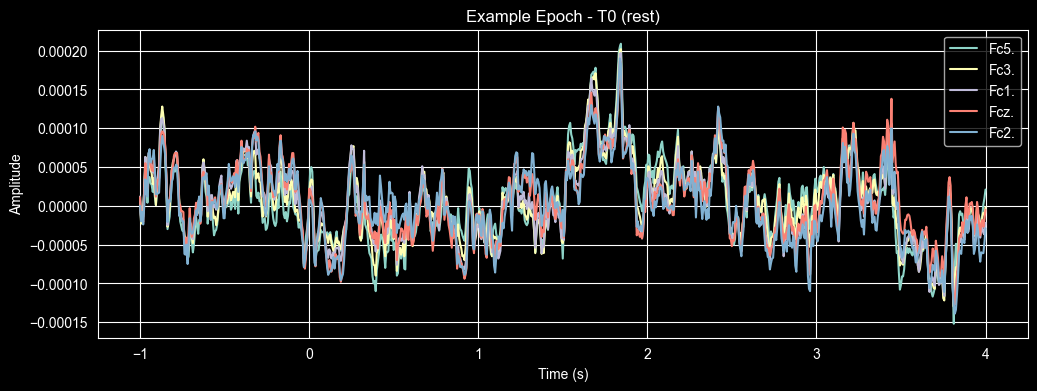

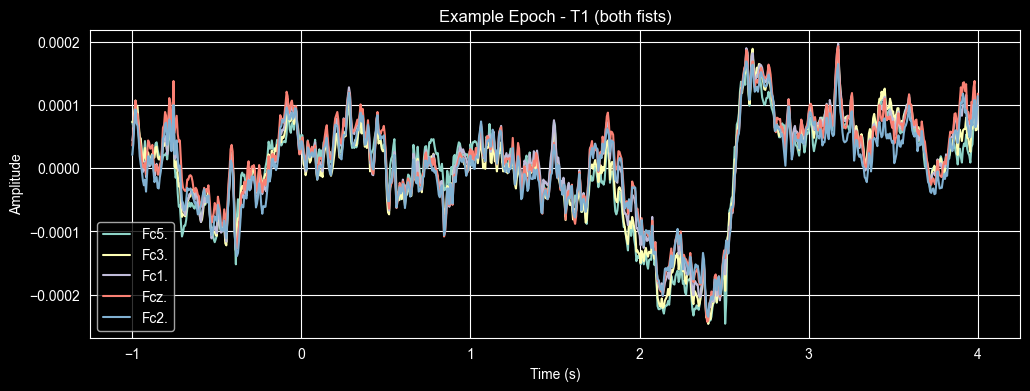

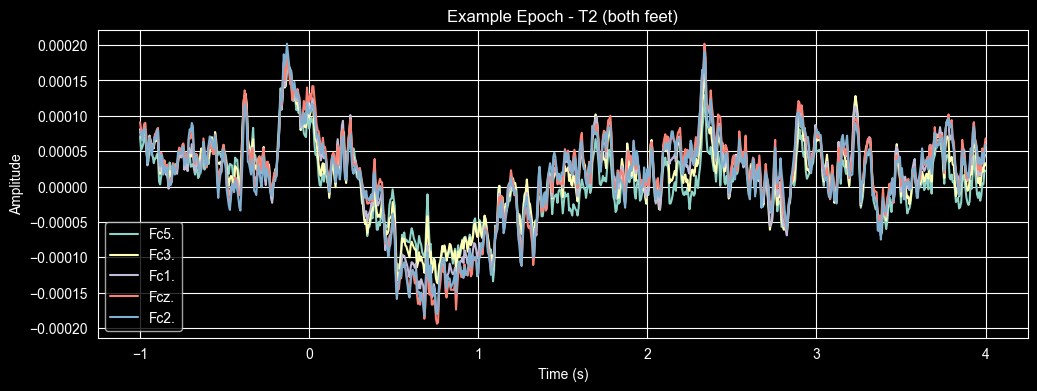

In [13]:
example_indices = {}
for label in ["T0", "T1", "T2"]:
    idx = np.where(labels_name == label)[0][0]
    example_indices[label] = idx

channels_to_plot = [0, 1, 2, 3, 4]

for label, idx in example_indices.items():
    plt.figure(figsize=(12, 4))
    for ch in channels_to_plot:
        plt.plot(epochs.times, data[idx, ch, :], label=epochs.ch_names[ch])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Example Epoch - {label} ({label_meaning[label]})")
    plt.legend()
    plt.show()

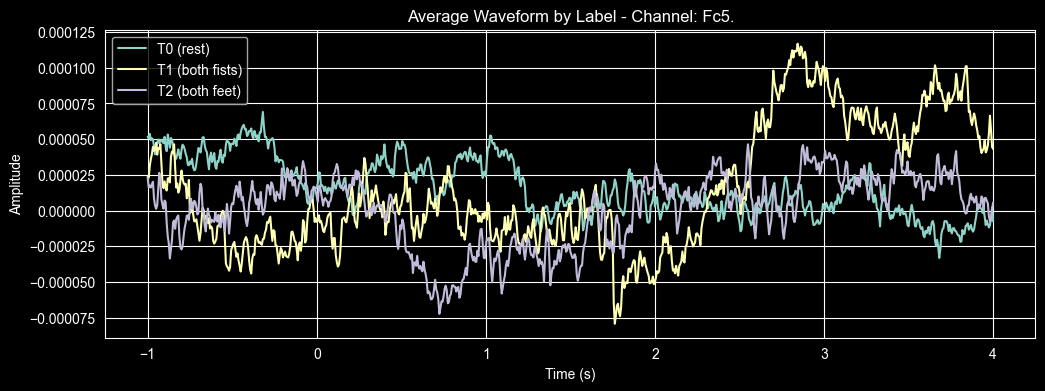

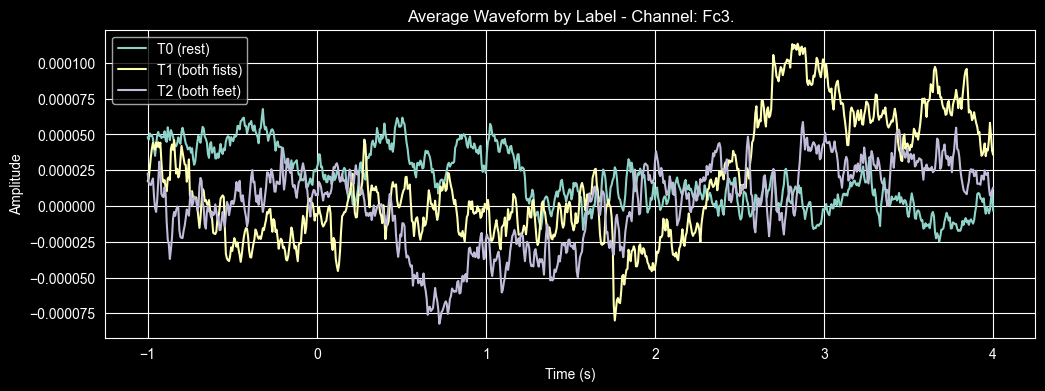

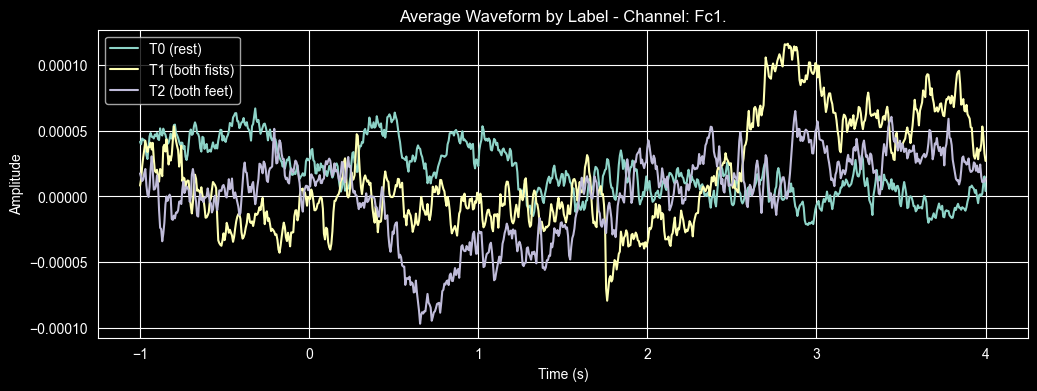

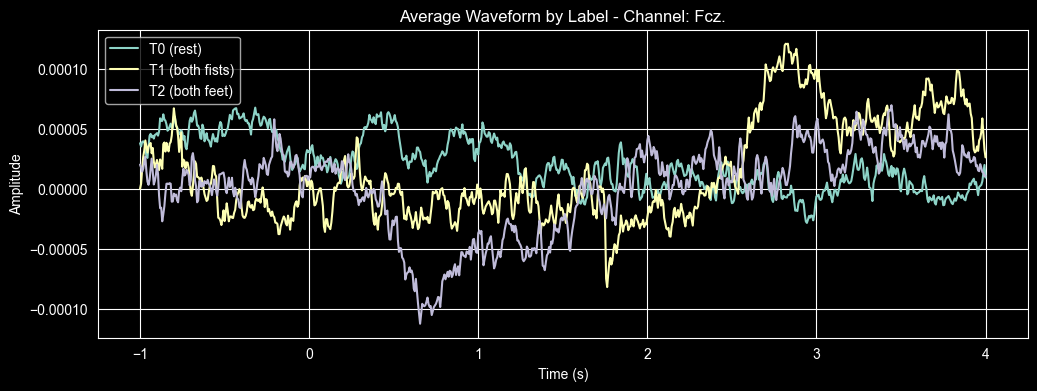

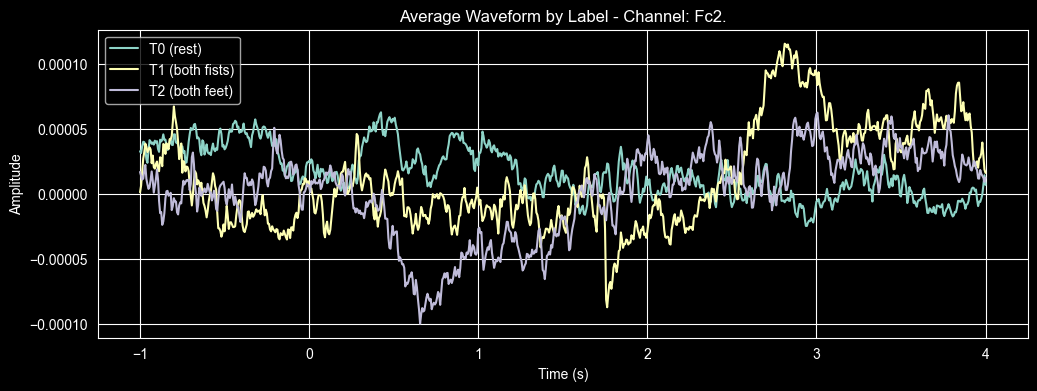

In [14]:
avg_by_label = {}
for label in ["T0", "T1", "T2"]:
    avg_by_label[label] = data[labels_name == label].mean(axis=0)  # shape: (channels, timepoints)

channels_to_plot = [0, 1, 2, 3, 4]
for ch in channels_to_plot:
    plt.figure(figsize=(12, 4))
    for label in ["T0", "T1", "T2"]:
        plt.plot(epochs.times, avg_by_label[label][ch], label=f"{label} ({label_meaning[label]})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Average Waveform by Label - Channel: {epochs.ch_names[ch]}")
    plt.legend()
    plt.show()

epoch std summary:
count    29.000000
mean      0.000059
std       0.000022
min       0.000043
25%       0.000048
50%       0.000051
75%       0.000063
max       0.000158
dtype: float64


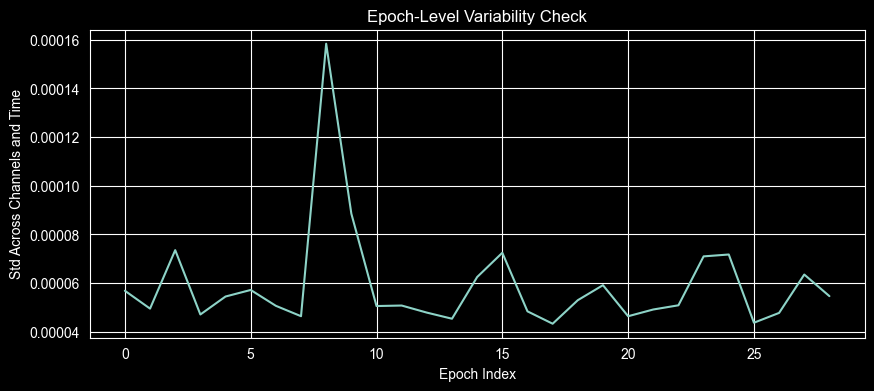

In [15]:
epoch_std = data.std(axis=(1, 2))
print("epoch std summary:")
print(pd.Series(epoch_std).describe())

plt.figure(figsize=(10, 4))
plt.plot(epoch_std)
plt.xlabel("Epoch Index")
plt.ylabel("Std Across Channels and Time")
plt.title("Epoch-Level Variability Check")
plt.show()


max std epoch index: 8 value: 0.0001583488297223118
min std epoch index: 17 value: 4.3349792201685044e-05


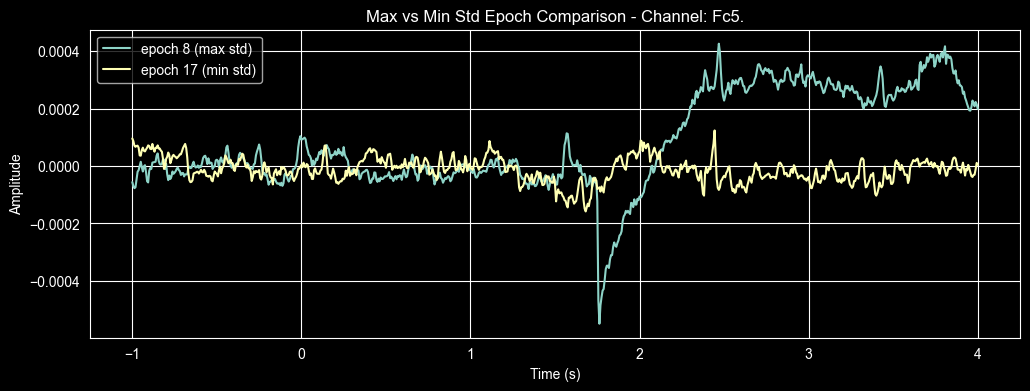

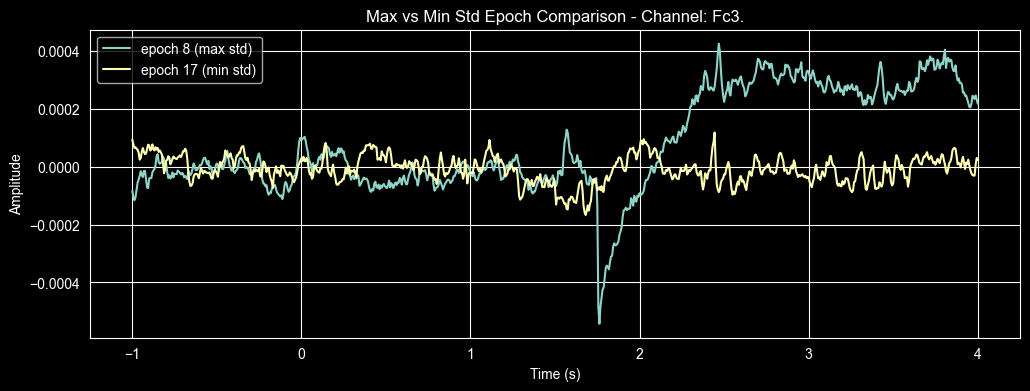

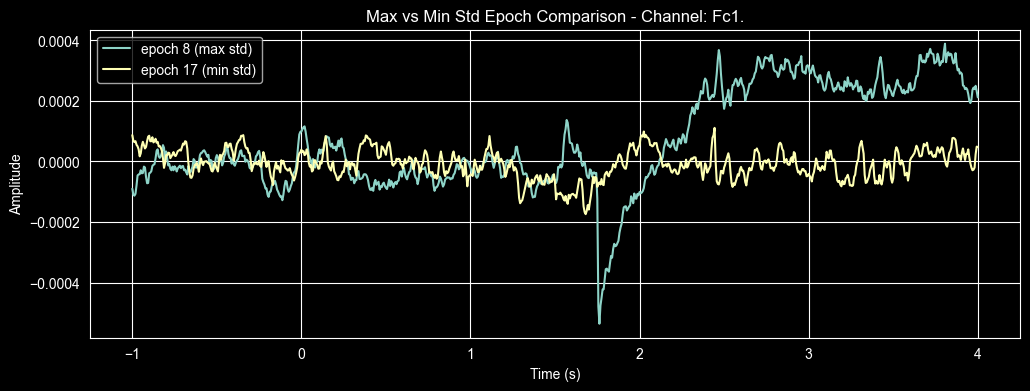

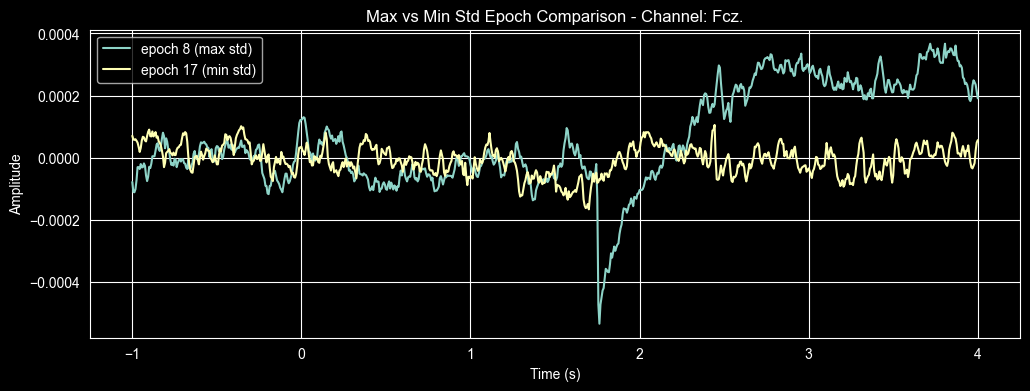

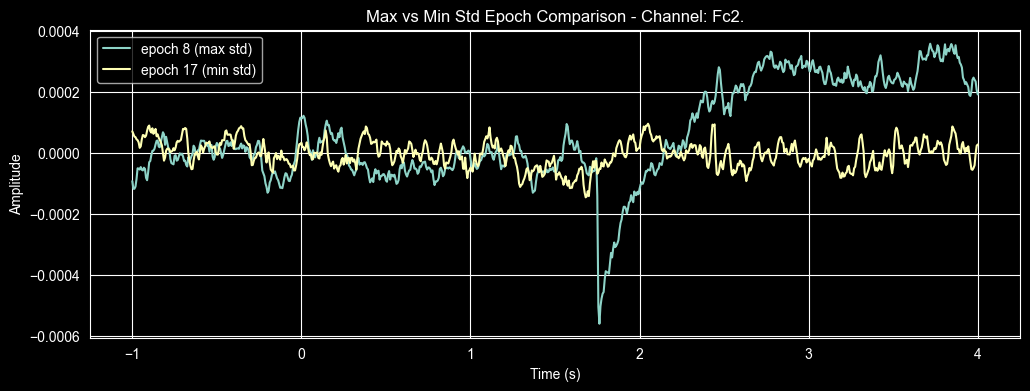

In [16]:
max_idx = epoch_std.argmax()
min_idx = epoch_std.argmin()

print("max std epoch index:", max_idx, "value:", epoch_std[max_idx])
print("min std epoch index:", min_idx, "value:", epoch_std[min_idx])

channels_to_plot = [0, 1, 2, 3, 4]
for ch in channels_to_plot:
    plt.figure(figsize=(12, 4))

    plt.plot(epochs.times, data[max_idx][ch], label=f"epoch {max_idx} (max std)")
    plt.plot(epochs.times, data[min_idx][ch], label=f"epoch {min_idx} (min std)")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Max vs Min Std Epoch Comparison - Channel: {epochs.ch_names[ch]}")
    plt.legend()
    plt.show()

In [17]:
X = data.reshape(data.shape[0], -1)
y = labels_name.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("labels:", np.unique(y))

X shape: (29, 51264)
y shape: (29,)
labels: ['T0' 'T1' 'T2']


In [18]:
import pandas as pd

label_counts = pd.Series(y).value_counts()
majority_class = label_counts.idxmax()
majority_acc = label_counts.max() / len(y)

print("majority class:", majority_class)
print("majority baseline accuracy:", majority_acc)
print(label_counts)

majority class: T0
majority baseline accuracy: 0.4827586206896552
T0    14
T2     8
T1     7
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train counts:")
print(pd.Series(y_train).value_counts())
print("y_test counts:")
print(pd.Series(y_test).value_counts())

X_train: (20, 51264)
X_test: (9, 51264)
y_train counts:
T0    10
T2     5
T1     5
Name: count, dtype: int64
y_test counts:
T0    4
T2    3
T1    2
Name: count, dtype: int64


In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

clf = make_pipeline(
    StandardScaler(),
    LinearSVC(random_state=42, max_iter=5000)
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("train done")
print("y_pred:", y_pred)

train done
y_pred: ['T0' 'T2' 'T2' 'T1' 'T0' 'T1' 'T2' 'T0' 'T0']


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["T0", "T1", "T2"])

print("accuracy:", acc)
print()
print("classification report:")
print(classification_report(y_test, y_pred))
print()
print("confusion matrix:")
print(cm)

accuracy: 1.0

classification report:
              precision    recall  f1-score   support

          T0       1.00      1.00      1.00         4
          T1       1.00      1.00      1.00         2
          T2       1.00      1.00      1.00         3

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


confusion matrix:
[[4 0 0]
 [0 2 0]
 [0 0 3]]


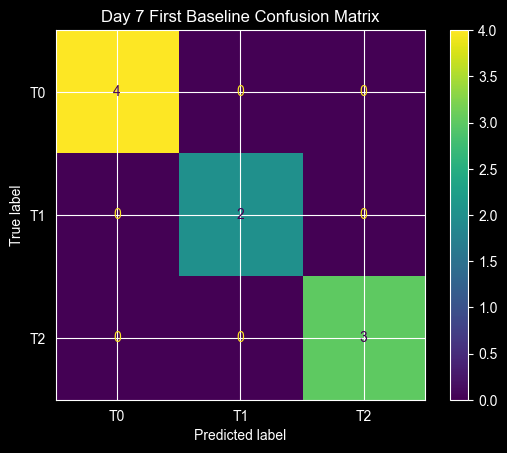

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["T0", "T1", "T2"]
)

disp.plot()
plt.title("Day 7 First Baseline Confusion Matrix")
plt.show()

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import numpy as np

clf = make_pipeline(
    StandardScaler(),
    LinearSVC(random_state=42, max_iter=10000)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv)

print("CV scores:", scores)
print("Mean CV accuracy:", np.mean(scores))
print("Std CV accuracy:", np.std(scores))

CV scores: [0.66666667 0.66666667 1.         0.66666667 0.8       ]
Mean CV accuracy: 0.76
Std CV accuracy: 0.13063945294843618
